# March Madness 2026 — Log-Loss Optimized Prediction Pipeline

## Competition Overview
- **Competition**: Fordham University NCAA March Madness prediction competition
- **Metric**: **Log-Loss** (NOT Brier Score like Kaggle)
- **Scope**: Men's tournament only (66,430 pairwise matchups)
- **Deadline**: March 19, 2026 at 1PM

## Why Log-Loss Matters
Log-loss punishes **overconfident wrong predictions catastrophically**. If you predict 0.95 for a team that loses, the penalty is -ln(0.05) = 3.0 — roughly 10x worse than predicting 0.50. This means:
- We must be **well-calibrated** — if we say 70%, it should win ~70% of the time
- We must be **conservative** — clipping predictions to [0.05, 0.95] is essential
- Aggressive strategies that win under Brier score (e.g., picking all favorites at 0.99) would be **suicidal** here

---

## Data Architecture — What Goes Where

Understanding which data is used for what is critical. Here's the full picture:

### Training Data (What the model learns from)
| Data | Source | Seasons | Purpose |
|------|--------|---------|---------|
| **Tournament game outcomes** | `MNCAATourneyDetailedResults.csv` (Kaggle) | 2003-2025 | **Target variable** — who won each tournament game and by how much |

> **The model is trained ONLY on past tournament games (2003-2025).** There are ~1,449 unique tournament games across 22 seasons (no 2020 due to COVID).

### Feature Data (What describes each team)
Features are computed **per team per season** from regular season data. For a tournament game in season S, we use only season S regular season data:

| Feature Source | File | Seasons | What It Provides |
|----------------|------|---------|------------------|
| Box score averages | `MRegularSeasonDetailedResults.csv` (Kaggle) | 2003-2026 | Points, rebounds, blocks, fouls, etc. — 24 features |
| Elo ratings | `MRegularSeasonCompactResults.csv` (Kaggle) | 2003-2026 | Dynamic strength ratings computed from all regular season games — 3 features |
| GLM team quality | `MRegularSeasonDetailedResults.csv` (Kaggle) | 2003-2026 | OLS-based team strength from point differentials — 2 features |
| Massey ordinals | `MMasseyOrdinals.csv` (Kaggle) | 2003-2026 | Composite of 58 computer ranking systems — 2 features |
| Barttorvik metrics | `NCAA_Tourney_2002_2025.csv` (Fordham) + `barttorvik_2026.csv` (external) | 2002-2026 | Adjusted efficiency (AdjOE, AdjDE, Barthag) — 9 features |
| Tournament seeds | `MNCAATourneySeeds.csv` (Kaggle) | 2003-2025 | 1-16 seed for each team — 3 features |
| Recent form | `MRegularSeasonDetailedResults.csv` (Kaggle) | 2003-2026 | Last 14 days point differential — 1 feature |
| Win ratios | `MRegularSeasonDetailedResults.csv` (Kaggle) | 2003-2026 | Overall win percentage — 1 feature |

> **Important:** Features for season S are computed ONLY from season S regular season data. There is no information leakage from future seasons. For example, when training on the 2019 tournament, we use 2019 regular season stats as features — never stats from 2020+.

### 2026 Prediction Data (What we're predicting)
| Data | Source | Purpose |
|------|--------|---------|
| 2026 regular season stats | Kaggle CSVs (Season==2026) | Features for 2026 teams |
| 2026 Barttorvik metrics | `barttorvik_2026.csv` | AdjOE, AdjDE, Barthag for 2026 |
| Championship futures | `futures_2026.csv` (VegasInsider, March 12) | Market-implied team strengths — blended at 15% weight |
| Submission template | `SampleSubmissionStage2.csv` | 66,430 matchup pairs to predict |

> **2026 tournament games don't exist yet** — we can't train on them. We use all LOSO models (trained on 2003-2025) to make 2026 predictions.

### Validation Strategy: Leave-One-Season-Out (LOSO) Cross-Validation
```
For each season S in {2003, 2004, ..., 2019, 2021, 2022, 2023, 2024, 2025}:
    TRAIN on: All tournament games EXCEPT season S  (~1,380 games from 21 seasons)
    VALIDATE on: Season S tournament games only     (~67 games from 1 season)
    Features: Computed from season S regular season data (no leakage)
```

This gives us **22 out-of-fold predictions** (one per season, excluding 2020). We evaluate two ways:
- **Full LOSO (2003-2025)**: Log-loss across all 22 seasons -> overall model quality
- **Last 3 folds (2023-2025)**: Log-loss on most recent 3 seasons -> comparable to benchmark leaderboards

### Flow Diagram
```
TRAINING PHASE (2003-2025)

  Regular Season Data --> Feature Engineering --> Features per team/year
  (Kaggle + Fordham)      (Elo, GLM, Massey,     (41 features)
                           Barttorvik, BoxScore)
                                   |
                                   v
  Tournament Outcomes --> [Train/Val Split: LOSO] --> 3 Trained Models
  (Kaggle: 2003-2025)    Season S = validation       (22 models each)
                          Rest = training
                                   |
                                   v
                         OOF Predictions --> Ensemble Weights + Temp
                         (2003-2025)         Scaling Optimization

PREDICTION PHASE (2026)

  2026 Regular Season --> Feature Engineering --> 2026 Features
  (Kaggle + Barttorvik)   (same pipeline)         (41 features)
                                   |
                                   v
                         All 22 LOSO Models --> Average Predictions
                         predict 2026            (model averaging)
                                   |
                                   v
  Futures Odds ----------> Log5 H2H Probs --> 85% Model + 15% Futures
  (VegasInsider)           (Shin conversion)
                                   |
                                   v
                         submission_2026.csv (66,430 matchups)
```

---

## Our Approach: 3-Model Ensemble with Conservative Calibration

| Model | Type | Target | Calibration | Role |
|-------|------|--------|-------------|------|
| **M1** | XGBoost Regression | Point Differential | Spline/Isotonic -> Probability | Primary workhorse (Raddar approach) |
| **M2** | Logistic Regression | Win/Loss | Native probability | Stable, well-calibrated baseline |
| **M3** | XGBoost Classification | Win/Loss (log-loss) | Direct probability | Diversity in ensemble |

**Key differentiators from typical approaches:**
1. **Data doubling** — every game entered from both perspectives (symmetric model)
2. **Leave-One-Season-Out CV** — avoids data leakage across seasons
3. **Barttorvik adjusted efficiency metrics** — KenPom-equivalent features for historical + 2026
4. **GLM team quality scores** — OLS regression on point differentials
5. **58 Massey ranking systems** aggregated into composite features
6. **Championship futures from VegasInsider** — market-implied probabilities via Log5 formula
7. **Shin vig removal** — Z-score correction that properly handles multi-outcome markets
8. **Temperature scaling** — post-hoc calibration to optimize log-loss directly

## Step 1: Imports & Configuration

We use XGBoost for gradient boosting, scikit-learn for logistic regression and calibration,
and scipy for spline fitting, optimization, and temperature scaling.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from scipy.interpolate import UnivariateSpline
from scipy.optimize import minimize, minimize_scalar
from scipy.stats import norm
import tqdm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 999)
sns.set_palette("deep")

DATA_DIR = "march-machine-learning-mania-2026"
SEASON_START = 2003
CURRENT_SEASON = 2026
CLIP_LOW, CLIP_HIGH = 0.05, 0.95
FUTURES_BLEND = 0.15

print("Configuration loaded.")

Configuration loaded.


## Step 2: Load All Data Sources

### Kaggle Competition Data (`march-machine-learning-mania-2026/`)
These CSVs are provided by the Kaggle competition and cover **all D1 basketball** from 1985-2026:

| File | Seasons | Rows | Role in Pipeline |
|------|---------|------|------------------|
| `MRegularSeasonDetailedResults.csv` | 2003-2026 | ~90K games | **Feature source** — box scores used to compute team averages, Elo, GLM quality, form |
| `MRegularSeasonCompactResults.csv` | 1985-2026 | ~160K games | **Feature source** — used for Elo rating computation |
| `MNCAATourneyDetailedResults.csv` | 2003-2025 | ~1,449 games | **TRAINING TARGET** — tournament outcomes the model learns from |
| `MNCAATourneySeeds.csv` | 1985-2025 | ~2,200 entries | **Feature source** — seed is one of the strongest predictive features |
| `MMasseyOrdinals.csv` | 2003-2026 | ~6.7M rows | **Feature source** — 58 ranking systems aggregated into composite |
| `MTeams.csv` | — | 380 teams | **Mapping** — TeamID to team name |
| `SampleSubmissionStage2.csv` | 2026 | 131K rows | **Submission template** — all possible 2026 matchup pairs |

> **Note on 2026:** Regular season files (`MRegularSeason*`) include 2026 data because the regular season is over. Tournament files (`MNCAATourney*`) do NOT include 2026 because the tournament hasn't started yet. This is exactly the real-world scenario: we train on past tournaments, predict the upcoming one.

### Fordham-Provided Data
| File | Seasons | Rows | Role in Pipeline |
|------|---------|------|------------------|
| `NCAA_Tourney_2002_2025.csv` | 2002-2025 | 1,514 games | **Feature source** — Barttorvik adjusted efficiency metrics (AdjOE, AdjDE, Barthag, AdjTempo) for historical tournament teams |

### External Data (Scraped/Downloaded)
| File | Date | Rows | Role in Pipeline |
|------|------|------|------------------|
| `barttorvik_2026.csv` | Current season | 365 teams | **Feature source** — 2026 Barttorvik metrics (AdjOE, AdjDE, Barthag, AdjTempo) |
| `futures_2026.csv` | March 12, 2026 | 111 teams | **Prediction blending** — championship futures odds from VegasInsider, converted to fair probabilities via Shin conversion, then to head-to-head via Log5 |

In [19]:
print("Loading data...")
reg_detailed = pd.read_csv(f"{DATA_DIR}/MRegularSeasonDetailedResults.csv")
reg_compact = pd.read_csv(f"{DATA_DIR}/MRegularSeasonCompactResults.csv")
tourney_compact = pd.read_csv(f"{DATA_DIR}/MNCAATourneyCompactResults.csv")
tourney_detailed = pd.read_csv(f"{DATA_DIR}/MNCAATourneyDetailedResults.csv")
seeds = pd.read_csv(f"{DATA_DIR}/MNCAATourneySeeds.csv")
massey = pd.read_csv(f"{DATA_DIR}/MMasseyOrdinals.csv")
teams = pd.read_csv(f"{DATA_DIR}/MTeams.csv")
conferences = pd.read_csv(f"{DATA_DIR}/MTeamConferences.csv")
submission = pd.read_csv(f"{DATA_DIR}/SampleSubmissionStage2.csv")

reg_detailed = reg_detailed[reg_detailed["Season"] >= SEASON_START]
reg_compact = reg_compact[reg_compact["Season"] >= SEASON_START]
tourney_detailed = tourney_detailed[tourney_detailed["Season"] >= SEASON_START]
seeds = seeds[seeds["Season"] >= SEASON_START]

print(f"Regular season: {len(reg_detailed):,} games ({reg_detailed['Season'].min()}-{reg_detailed['Season'].max()})")
print(f"Tournament: {len(tourney_detailed):,} games")
print(f"2026 regular season games: {len(reg_detailed[reg_detailed['Season']==2026]):,}")

Loading data...
Regular season: 124,031 games (2003-2026)
Tournament: 1,449 games
2026 regular season games: 5,149


## Step 3: Data Doubling & Preprocessing

### Data Doubling
This is a critical technique used by top Kaggle competitors. Every game is entered **twice** — once from each team's perspective:
- Row 1: Team A (T1) beat Team B (T2) by +10
- Row 2: Team B (T1) lost to Team A (T2) by -10

**Why?** The model becomes **symmetric** — it learns "T1 is stronger than T2" regardless of which team is T1. Without doubling, the model would have a bias based on which team happened to be listed first. This doubles our training data and eliminates ordering artifacts.

### Overtime Normalization
Games that go to overtime have inflated stats (more minutes played). We normalize all box score statistics to a **40-minute equivalent**:
```
normalized_stat = raw_stat x 40 / (40 + 5 x num_overtimes)
```

### Seed Parsing
Seeds come as strings like `"W01"`, `"X16a"`. We extract the integer seed (1-16).

In [20]:
def prepare_data(df):
    cols = ["Season", "DayNum", "LTeamID", "LScore", "WTeamID", "WScore", "NumOT",
            "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
            "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]
    df = df[cols].copy()
    adjot = (40 + 5 * df["NumOT"]) / 40
    adj_cols = [c for c in cols if c not in ["Season", "DayNum", "NumOT", "LTeamID", "WTeamID"]]
    for col in adj_cols:
        df[col] = df[col] / adjot
    dfswap = df.copy()
    df.columns = [x.replace("W", "T1_").replace("L", "T2_") for x in df.columns]
    dfswap.columns = [x.replace("L", "T1_").replace("W", "T2_") for x in dfswap.columns]
    output = pd.concat([df, dfswap]).reset_index(drop=True)
    output["PointDiff"] = output["T1_Score"] - output["T2_Score"]
    output["win"] = (output["PointDiff"] > 0).astype(int)
    return output

regular_data = prepare_data(reg_detailed)
tourney_data = prepare_data(tourney_detailed)

seeds["seed"] = seeds["Seed"].apply(lambda x: int(x[1:3]))
seeds_T1 = seeds[["Season", "TeamID", "seed"]].copy()
seeds_T1.columns = ["Season", "T1_TeamID", "T1_seed"]
seeds_T2 = seeds[["Season", "TeamID", "seed"]].copy()
seeds_T2.columns = ["Season", "T2_TeamID", "T2_seed"]

tourney_data = tourney_data[["Season", "T1_TeamID", "T2_TeamID", "PointDiff", "win"]]
tourney_data = pd.merge(tourney_data, seeds_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, seeds_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["Seed_diff"] = tourney_data["T2_seed"] - tourney_data["T1_seed"]

print(f"Regular data (doubled): {len(regular_data):,} rows")
print(f"Tournament data (doubled): {len(tourney_data):,} rows")
print(f"Win rate (should be ~0.50): {tourney_data['win'].mean():.4f}")

Regular data (doubled): 248,062 rows
Tournament data (doubled): 2,898 rows
Win rate (should be ~0.50): 0.5000


## Step 4: Feature Engineering — Box Score Season Averages

For each team in each season, we compute the **mean of every box score statistic** across all regular season games. Because of data doubling, this naturally captures both offensive stats (when the team is T1) and the opponent's stats (T2 perspective).

### Features Generated (per team):
| Feature | Description |
|---------|-------------|
| `avg_Score` | Average points scored per game |
| `avg_FGA` | Average field goal attempts (shot volume) |
| `avg_OR` | Average offensive rebounds (second-chance opportunities) |
| `avg_DR` | Average defensive rebounds (limiting opponent second chances) |
| `avg_Blk` | Average blocks (rim protection) |
| `avg_PF` | Average personal fouls (discipline) |
| `avg_opponent_FGA` | Opponent's shot volume (defensive pressure) |
| `avg_opponent_Blk` | Opponent's blocks against us |
| `avg_opponent_PF` | Opponent's fouls (our ability to draw fouls) |
| `avg_PointDiff` | Average margin of victory (overall team strength) |

**Note**: We deliberately exclude some stats (FGM, FGM3, FTA, Ast, TO, Stl) from the model features to reduce multicollinearity — they're highly correlated with the included stats. The model uses 24 box score features total (12 per team).

In [21]:
print("Computing box score season averages...")
boxcols = [
    "T1_Score", "T1_FGM", "T1_FGA", "T1_FGM3", "T1_FGA3", "T1_FTM", "T1_FTA",
    "T1_OR", "T1_DR", "T1_Ast", "T1_TO", "T1_Stl", "T1_Blk", "T1_PF",
    "T2_Score", "T2_FGM", "T2_FGA", "T2_FGM3", "T2_FGA3", "T2_FTM", "T2_FTA",
    "T2_OR", "T2_DR", "T2_Ast", "T2_TO", "T2_Stl", "T2_Blk", "T2_PF",
    "PointDiff",
]
ss = regular_data.groupby(["Season", "T1_TeamID"])[boxcols].agg("mean").reset_index()
ss_T1 = ss.copy()
ss_T1.columns = ["T1_avg_" + x.replace("T1_", "").replace("T2_", "opponent_") for x in ss_T1.columns]
ss_T1 = ss_T1.rename({"T1_avg_Season": "Season", "T1_avg_TeamID": "T1_TeamID"}, axis=1)
ss_T2 = ss.copy()
ss_T2.columns = ["T2_avg_" + x.replace("T1_", "").replace("T2_", "opponent_") for x in ss_T2.columns]
ss_T2 = ss_T2.rename({"T2_avg_Season": "Season", "T2_avg_TeamID": "T2_TeamID"}, axis=1)
tourney_data = pd.merge(tourney_data, ss_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, ss_T2, on=["Season", "T2_TeamID"], how="left")
print(f"Box score features added. Shape: {tourney_data.shape}")

Computing box score season averages...
Box score features added. Shape: (2898, 66)


## Step 5: Feature Engineering — Elo Ratings

Elo is a dynamic rating system that updates after every game. Each team starts at **1000** at the beginning of each season (no carry-over between seasons).

### How Elo Works
After each game:
```
expected_win_prob = 1 / (1 + 10^((loser_elo - winner_elo) / 400))
elo_change = K x (1 - expected_win_prob)
winner_elo += elo_change
loser_elo  -= elo_change
```

### Parameters
- **K-factor = 100**: How much each game matters. Higher K = more reactive to recent results.
- **Width = 400**: Controls the spread of the Elo distribution.
- **Reset each season**: Prevents carry-over effects (roster turnover makes prior seasons less relevant).

### Why Elo?
- Captures **strength of schedule** (beating a 1200-rated team gives more Elo than beating an 800-rated team)
- Naturally accounts for **game order** (recent wins matter through accumulated rating)
- Simple, interpretable, and computationally cheap

### Features Generated
| Feature | Description |
|---------|-------------|
| `T1_elo` | Team 1's end-of-regular-season Elo rating |
| `T2_elo` | Team 2's end-of-regular-season Elo rating |
| `elo_diff` | T1_elo - T2_elo (positive = T1 is stronger) |

In [22]:
print("Computing Elo ratings...")
def update_elo(winner_elo, loser_elo, k_factor=100, elo_width=400):
    expected = 1.0 / (1 + 10 ** ((loser_elo - winner_elo) / elo_width))
    change = k_factor * (1 - expected)
    return winner_elo + change, loser_elo - change

elos_list = []
for season in sorted(set(reg_compact["Season"])):
    ss_games = reg_compact[reg_compact["Season"] == season]
    team_ids = set(ss_games["WTeamID"]) | set(ss_games["LTeamID"])
    elo = {t: 1000 for t in team_ids}
    for row in ss_games.itertuples(index=False):
        elo[row.WTeamID], elo[row.LTeamID] = update_elo(elo[row.WTeamID], elo[row.LTeamID])
    elo_df = pd.DataFrame({"TeamID": list(elo.keys()), "elo": list(elo.values()), "Season": season})
    elos_list.append(elo_df)

elos = pd.concat(elos_list)
elos_T1 = elos.rename({"TeamID": "T1_TeamID", "elo": "T1_elo"}, axis=1)
elos_T2 = elos.rename({"TeamID": "T2_TeamID", "elo": "T2_elo"}, axis=1)
tourney_data = pd.merge(tourney_data, elos_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, elos_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["elo_diff"] = tourney_data["T1_elo"] - tourney_data["T2_elo"]
print(f"Elo computed. 2026 teams: {len(elos[elos['Season']==2026])}")

Computing Elo ratings...
Elo computed. 2026 teams: 365


## Step 6: Feature Engineering — GLM Team Quality Scores

### The Idea
We fit a simple linear model for each season:
```
PointDiff = beta_T1 - beta_T2 + epsilon
```
Each team gets a single coefficient beta that represents its "quality" — how many points better (or worse) it is than an average team. This is solved via OLS (Ordinary Least Squares).

### How It Differs From Simple Stats
- **Adjusts for strength of schedule**: A team that beats strong opponents by 5 points gets a higher quality score than one that beats weak opponents by 10
- **Uses only tournament-relevant teams**: We filter to teams that made the tournament + teams that beat tournament teams. This focuses the model on the competitive landscape that matters.

### 2026 Proxy Seeds
Since 2026 tournament seeds aren't available until Selection Sunday (March 15), we use the **top 68 teams by POM ranking** (a KenPom-equivalent from Massey Ordinals) as proxy tournament teams.

### Features Generated
| Feature | Description |
|---------|-------------|
| `T1_quality` | Team 1's GLM quality coefficient (points above average) |
| `T2_quality` | Team 2's GLM quality coefficient |

In [23]:
print("Computing GLM team quality...")
regular_data["ST1"] = regular_data["Season"].astype(int).astype(str) + "/" + regular_data["T1_TeamID"].astype(int).astype(str)
regular_data["ST2"] = regular_data["Season"].astype(int).astype(str) + "/" + regular_data["T2_TeamID"].astype(int).astype(str)
seeds_T1["ST1"] = seeds_T1["Season"].astype(int).astype(str) + "/" + seeds_T1["T1_TeamID"].astype(int).astype(str)
seeds_T2["ST2"] = seeds_T2["Season"].astype(int).astype(str) + "/" + seeds_T2["T2_TeamID"].astype(int).astype(str)

st = set(seeds_T1["ST1"]) | set(seeds_T2["ST2"])
st = st | set(regular_data.loc[(regular_data["T1_Score"] > regular_data["T2_Score"]) & (regular_data["ST2"].isin(st)), "ST1"])

massey_2026 = massey[(massey["Season"] == 2026) & (massey["SystemName"] == "POM")]
if len(massey_2026) > 0:
    latest_day = massey_2026["RankingDayNum"].max()
    pom_latest = massey_2026[massey_2026["RankingDayNum"] == latest_day].nsmallest(68, "OrdinalRank")
    for _, row in pom_latest.iterrows():
        st.add(f"2026/{int(row['TeamID'])}")
    st_2026 = {s for s in st if s.startswith("2026/")}
    st = st | set(regular_data.loc[(regular_data["Season"] == 2026) & (regular_data["T1_Score"] > regular_data["T2_Score"]) & (regular_data["ST2"].isin(st_2026)), "ST1"])

def team_quality(season, dt):
    data = dt.loc[dt["Season"] == season].copy()
    if len(data) < 50:
        return pd.DataFrame(columns=["TeamID", "quality", "Season"])
    all_teams = sorted(set(data["T1_TeamID"]) | set(data["T2_TeamID"]))
    team_to_idx = {t: i for i, t in enumerate(all_teams)}
    n_teams, n_games = len(all_teams), len(data)
    X = np.zeros((n_games, n_teams))
    t1_ids, t2_ids, y = data["T1_TeamID"].values, data["T2_TeamID"].values, data["PointDiff"].values
    for i in range(n_games):
        X[i, team_to_idx[t1_ids[i]]] = 1
        X[i, team_to_idx[t2_ids[i]]] = -1
    try:
        quality_vals = np.linalg.lstsq(X, y, rcond=None)[0]
    except np.linalg.LinAlgError:
        return pd.DataFrame(columns=["TeamID", "quality", "Season"])
    quality = pd.DataFrame({"TeamID": all_teams, "quality": quality_vals, "Season": season})
    quality = quality[quality["TeamID"] != "0000"]
    quality["TeamID"] = quality["TeamID"].astype(int)
    return quality

dt = regular_data.loc[regular_data["ST1"].isin(st) | regular_data["ST2"].isin(st)].copy()
dt["T1_TeamID"] = dt["T1_TeamID"].astype(str)
dt["T2_TeamID"] = dt["T2_TeamID"].astype(str)
dt.loc[~dt["ST1"].isin(st), "T1_TeamID"] = "0000"
dt.loc[~dt["ST2"].isin(st), "T2_TeamID"] = "0000"

glm_quality = []
for s in tqdm.tqdm(sorted(set(seeds["Season"]) | {2026}), desc="GLM"):
    if s >= SEASON_START:
        glm_quality.append(team_quality(s, dt))
glm_quality = pd.concat(glm_quality).reset_index(drop=True)
glm_quality_T1 = glm_quality.rename({"TeamID": "T1_TeamID", "quality": "T1_quality"}, axis=1)
glm_quality_T2 = glm_quality.rename({"TeamID": "T2_TeamID", "quality": "T2_quality"}, axis=1)
tourney_data = pd.merge(tourney_data, glm_quality_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, glm_quality_T2, on=["Season", "T2_TeamID"], how="left")
print(f"GLM quality computed.")

Computing GLM team quality...


GLM: 100%|██████████| 23/23 [00:01<00:00, 16.82it/s]

GLM quality computed.


## Step 7: Feature Engineering — Massey Ordinal Composite Rankings

### What Are Massey Ordinals?
Kaggle provides rankings from **58 different computer ranking systems** (Sagarin, KenPom/POM, BPI, RPI, etc.) for each team, updated throughout the season. Each system uses its own methodology — some emphasize margin of victory, others focus on strength of schedule, some use Bayesian methods, etc.

### Our Approach
Rather than picking one system, we **aggregate all 58 systems** into a composite:
- **`massey_median`**: Median rank across all systems (robust to outlier systems)
- **`massey_mean`**: Mean rank (captures full distribution)
- **`pom_rank`**: POM ranking separately — this is the closest proxy to KenPom, the gold standard in college basketball analytics

### Why Median Over Mean?
The median is more robust to outlier ranking systems that may have unusual methodologies. If 57 systems rank a team in the top 10 but one quirky system ranks them 150th, the median ignores that outlier while the mean would be pulled up.

### Features Generated
| Feature | Description |
|---------|-------------|
| `massey_diff` | T1_massey_median - T2_massey_median (negative = T1 ranked higher) |
| `pom_diff` | T1_pom_rank - T2_pom_rank (negative = T1 ranked higher) |

In [24]:
print("Computing Massey ordinals...")
def compute_massey_features(massey_df, season):
    s = massey_df[massey_df["Season"] == season]
    if len(s) == 0:
        return pd.DataFrame(columns=["TeamID", "massey_median", "massey_mean", "pom_rank", "Season"])
    latest = s.groupby(["SystemName", "TeamID"])["RankingDayNum"].max().reset_index()
    s = s.merge(latest, on=["SystemName", "TeamID", "RankingDayNum"])
    composite = s.groupby("TeamID")["OrdinalRank"].agg(["mean", "median"]).reset_index()
    composite.columns = ["TeamID", "massey_mean", "massey_median"]
    pom = s[s["SystemName"] == "POM"][["TeamID", "OrdinalRank"]].rename(columns={"OrdinalRank": "pom_rank"})
    composite = composite.merge(pom, on="TeamID", how="left")
    composite["Season"] = season
    return composite

massey_features = []
for season in tqdm.tqdm(sorted(set(massey["Season"])), desc="Massey"):
    massey_features.append(compute_massey_features(massey, season))
massey_features = pd.concat(massey_features)

massey_T1 = massey_features.rename(columns={"TeamID": "T1_TeamID", "massey_median": "T1_massey_median", "massey_mean": "T1_massey_mean", "pom_rank": "T1_pom_rank"})
massey_T2 = massey_features.rename(columns={"TeamID": "T2_TeamID", "massey_median": "T2_massey_median", "massey_mean": "T2_massey_mean", "pom_rank": "T2_pom_rank"})
tourney_data = pd.merge(tourney_data, massey_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, massey_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["massey_diff"] = tourney_data["T1_massey_median"] - tourney_data["T2_massey_median"]
tourney_data["pom_diff"] = tourney_data["T1_pom_rank"] - tourney_data["T2_pom_rank"]
print(f"Massey features added.")

Computing Massey ordinals...


Massey: 100%|██████████| 24/24 [00:01<00:00, 22.64it/s]

Massey features added.


## Step 8: Feature Engineering — Barttorvik Adjusted Efficiency Metrics

### What Is Barttorvik?
Barttorvik (barttorvik.com) provides **tempo-free, schedule-adjusted efficiency metrics** — essentially a free alternative to KenPom (the gold standard for college basketball analytics). These metrics answer: "How good is this team after adjusting for opponent strength and game pace?"

### Key Metrics
| Metric | Description |
|--------|-------------|
| **AdjOE** (Adjusted Offensive Efficiency) | Points scored per 100 possessions, adjusted for opponent defense quality. ~110+ is elite. |
| **AdjDE** (Adjusted Defensive Efficiency) | Points allowed per 100 possessions, adjusted for opponent offense quality. ~95 or lower is elite. |
| **Barthag** | Win probability vs. average team. Computed as: `AdjOE^11.5 / (AdjOE^11.5 + AdjDE^11.5)`. Values >0.9 indicate top-tier teams. |
| **AdjTempo** | Possessions per 40 minutes, adjusted for opponent pace. ~70 is average. |

### Data Sources
- **Historical (2002-2025)**: Extracted from `NCAA_Tourney_2002_2025.csv` which has per-team Barttorvik metrics for every tournament game
- **2026**: Downloaded from `barttorvik_2026.csv` (365 D1 teams)

### Why These Matter
Adjusted efficiency is the **single most predictive family of features** in college basketball. Raw stats (points per game, rebounds, etc.) are confounded by pace and schedule — a team that plays fast will score more points but also allow more, regardless of quality. Barttorvik strips out these confounds.

### Features Generated
| Feature | Description |
|---------|-------------|
| `T1_bt_adjoe`, `T2_bt_adjoe` | Adjusted offensive efficiency for each team |
| `T1_bt_adjde`, `T2_bt_adjde` | Adjusted defensive efficiency for each team |
| `T1_bt_barthag`, `T2_bt_barthag` | Win probability vs. average team |
| `bt_adjoe_diff` | Offensive efficiency advantage (T1 - T2) |
| `bt_adjde_diff` | Defensive efficiency advantage (T1 - T2; negative = T1 is better) |
| `bt_barthag_diff` | Overall quality advantage |

In [25]:
print("Loading Barttorvik metrics...")
ncaa_hist = pd.read_csv("NCAA_Tourney_2002_2025.csv")
bt_hist_parts = []
for prefix, id_col in [("team1", "team1_id"), ("team2", "team2_id")]:
    part = ncaa_hist[["season", id_col, f"{prefix}_adjoe", f"{prefix}_adjde", f"{prefix}_tempo", f"{prefix}_adjtempo"]].copy()
    adjoe, adjde = part[f"{prefix}_adjoe"], part[f"{prefix}_adjde"]
    part["barthag"] = adjoe**11.5 / (adjoe**11.5 + adjde**11.5)
    part.columns = ["Season", "TeamID", "bt_adjoe", "bt_adjde", "bt_tempo", "bt_adjtempo", "bt_barthag"]
    bt_hist_parts.append(part)
bt_hist = pd.concat(bt_hist_parts).drop_duplicates(subset=["Season", "TeamID"]).reset_index(drop=True)
bt_hist["TeamID"] = bt_hist["TeamID"].astype(int)

bt = pd.read_csv("barttorvik_2026.csv")
team_spellings = pd.read_csv(f"{DATA_DIR}/MTeamSpellings.csv", encoding="latin-1")

def normalize_name(name):
    return str(name).lower().strip().replace(".", "").replace("'", "").replace("-", " ").replace("  ", " ")

bt["team_norm"] = bt["team"].apply(normalize_name)
team_spellings["spell_norm"] = team_spellings["TeamNameSpelling"].apply(normalize_name)
teams["name_norm"] = teams["TeamName"].apply(normalize_name)

name_to_id = {}
for _, row in team_spellings.iterrows():
    name_to_id[row["spell_norm"]] = row["TeamID"]
for _, row in teams.iterrows():
    name_to_id[row["name_norm"]] = row["TeamID"]
bt["TeamID"] = bt["team_norm"].map(name_to_id)

unmapped = bt[bt["TeamID"].isna()]["team"].tolist()
if unmapped:
    kaggle_names = {row["name_norm"]: row["TeamID"] for _, row in teams.iterrows()}
    for bt_name in unmapped:
        norm = normalize_name(bt_name)
        for kn, kid in kaggle_names.items():
            if norm in kn or kn in norm:
                name_to_id[norm] = kid
                break
    bt["TeamID"] = bt["team_norm"].map(name_to_id)

bt_2026 = bt[bt["TeamID"].notna()][["TeamID", "adjoe", "adjde", "barthag", "adjt"]].copy()
bt_2026["TeamID"] = bt_2026["TeamID"].astype(int)
bt_2026["Season"] = 2026
bt_2026.columns = ["TeamID", "bt_adjoe", "bt_adjde", "bt_barthag", "bt_adjtempo", "Season"]

bt_all = pd.concat([bt_hist[["Season", "TeamID", "bt_adjoe", "bt_adjde", "bt_barthag", "bt_adjtempo"]],
                     bt_2026[["Season", "TeamID", "bt_adjoe", "bt_adjde", "bt_barthag", "bt_adjtempo"]]], ignore_index=True)
bt_all = bt_all.drop_duplicates(subset=["Season", "TeamID"])

bt_T1 = bt_all.rename(columns={"TeamID": "T1_TeamID", "bt_adjoe": "T1_bt_adjoe", "bt_adjde": "T1_bt_adjde", "bt_barthag": "T1_bt_barthag", "bt_adjtempo": "T1_bt_adjtempo"})
bt_T2 = bt_all.rename(columns={"TeamID": "T2_TeamID", "bt_adjoe": "T2_bt_adjoe", "bt_adjde": "T2_bt_adjde", "bt_barthag": "T2_bt_barthag", "bt_adjtempo": "T2_bt_adjtempo"})

tourney_data = pd.merge(tourney_data, bt_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, bt_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["bt_adjoe_diff"] = tourney_data["T1_bt_adjoe"] - tourney_data["T2_bt_adjoe"]
tourney_data["bt_adjde_diff"] = tourney_data["T1_bt_adjde"] - tourney_data["T2_bt_adjde"]
tourney_data["bt_barthag_diff"] = tourney_data["T1_bt_barthag"] - tourney_data["T2_bt_barthag"]
bt_coverage = tourney_data["bt_adjoe_diff"].notna().sum() / len(tourney_data) * 100
print(f"Barttorvik merged. Coverage: {bt_coverage:.1f}%")

Loading Barttorvik metrics...
Barttorvik merged. Coverage: 99.6%


## Step 9: Feature Engineering — Recent Form & Win Ratios

### Recent Form
A team's **average point differential over the last 14 days** of the regular season. This captures late-season momentum — teams peaking at the right time vs. teams that faded.

### Win Ratios
Simple **overall win percentage** across the regular season. While crude compared to other features, it provides a sanity-check signal and captures something about consistency.

### Features Generated
| Feature | Description |
|---------|-------------|
| `form_diff` | Recent form advantage (T1 last-14-day avg margin - T2 last-14-day avg margin) |
| `wr_diff` | Win ratio advantage (T1 win% - T2 win%) |

In [26]:
print("Computing form and win ratios...")
def compute_recent_form(regular_data, n_days=14):
    form_list = []
    for season in sorted(regular_data["Season"].unique()):
        s = regular_data[regular_data["Season"] == season]
        recent = s[s["DayNum"] >= s["DayNum"].max() - n_days]
        form = recent.groupby("T1_TeamID")["PointDiff"].mean().reset_index()
        form.columns = ["TeamID", "recent_form"]
        form["Season"] = season
        form_list.append(form)
    return pd.concat(form_list)

def compute_win_ratios(regular_data):
    ratios = []
    for season in sorted(regular_data["Season"].unique()):
        s = regular_data[regular_data["Season"] == season]
        total = s.groupby("T1_TeamID")["win"].agg(["mean", "count"]).reset_index()
        total.columns = ["TeamID", "win_ratio", "games_played"]
        total["Season"] = season
        ratios.append(total)
    return pd.concat(ratios)

form = compute_recent_form(regular_data)
form_T1 = form.rename(columns={"TeamID": "T1_TeamID", "recent_form": "T1_recent_form"})
form_T2 = form.rename(columns={"TeamID": "T2_TeamID", "recent_form": "T2_recent_form"})
win_ratios = compute_win_ratios(regular_data)
wr_T1 = win_ratios[["Season", "TeamID", "win_ratio"]].rename(columns={"TeamID": "T1_TeamID", "win_ratio": "T1_win_ratio"})
wr_T2 = win_ratios[["Season", "TeamID", "win_ratio"]].rename(columns={"TeamID": "T2_TeamID", "win_ratio": "T2_win_ratio"})

tourney_data = pd.merge(tourney_data, form_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, form_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, wr_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, wr_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["form_diff"] = tourney_data["T1_recent_form"] - tourney_data["T2_recent_form"]
tourney_data["wr_diff"] = tourney_data["T1_win_ratio"] - tourney_data["T2_win_ratio"]
print(f"Final tourney shape: {tourney_data.shape}")

Computing form and win ratios...
Final tourney shape: (2898, 96)


## Step 10: Define Feature Sets & Exploratory Analysis

We use **different feature sets** for different models:

### Model 1 & 3 (XGBoost): 41 features
XGBoost can handle correlated features and non-linear interactions, so we give it **everything**:
- Seeds (3): T1_seed, T2_seed, Seed_diff
- Box score averages (24): Score, FGA, OR, DR, Blk, PF, opponent_FGA/Blk/PF, PointDiff x 2 teams
- Elo (3): T1_elo, T2_elo, elo_diff
- GLM quality (2): T1_quality, T2_quality
- Massey composite (2): massey_diff, pom_diff
- Barttorvik (9): AdjOE, AdjDE, Barthag x 2 teams + 3 diffs
- Form/momentum (2): form_diff, wr_diff

### Model 2 (Logistic Regression): 11 features
Logistic regression works best with **diff features** (avoiding multicollinearity from paired team stats):
- Seed_diff, elo_diff, massey_diff, pom_diff, form_diff, wr_diff
- T1/T2 avg PointDiff (the strongest raw stat)
- bt_adjoe_diff, bt_adjde_diff, bt_barthag_diff

Clean data: 2886 rows, 22 seasons
M1: 41 features, M2: 11 features


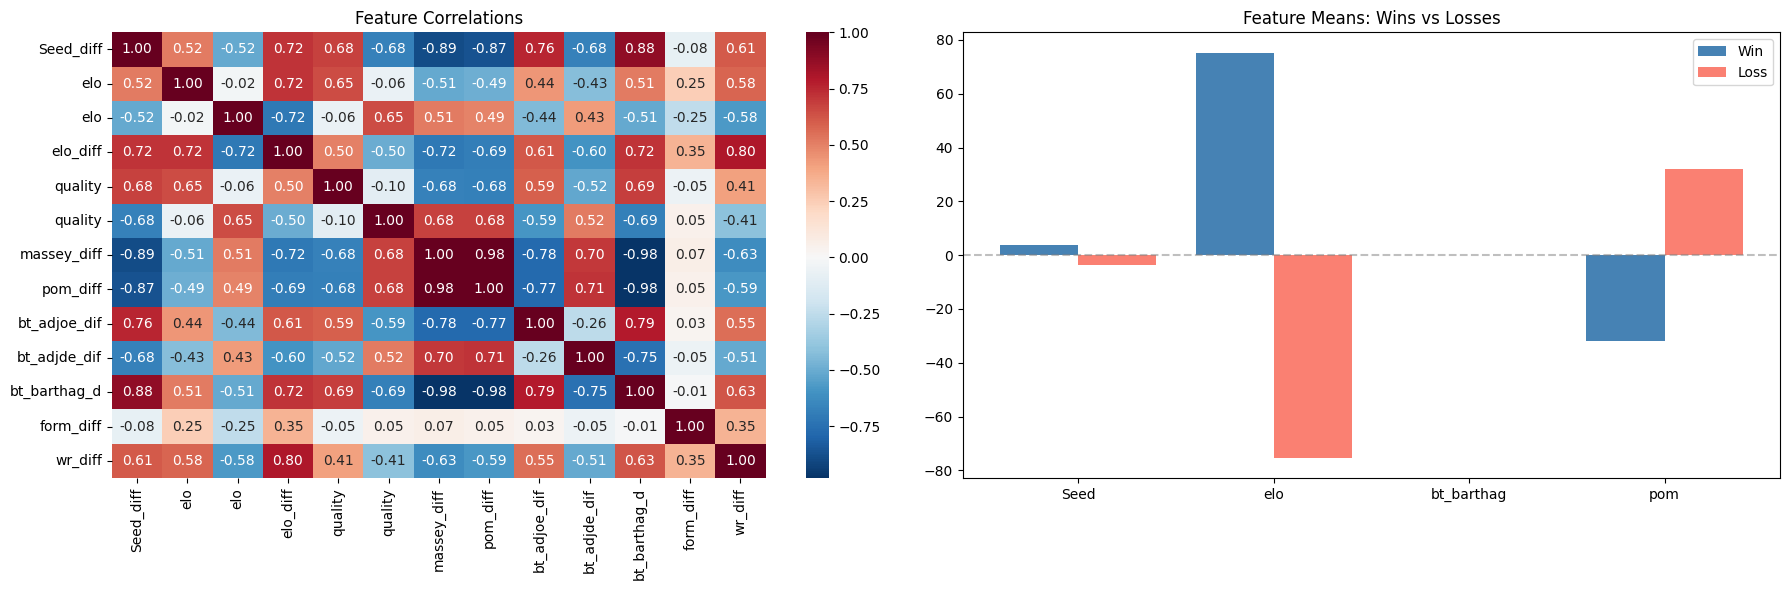

In [27]:
features_m1 = [
    "T1_seed", "T2_seed", "Seed_diff",
    "T1_avg_Score", "T1_avg_FGA", "T1_avg_OR", "T1_avg_DR",
    "T1_avg_Blk", "T1_avg_PF",
    "T1_avg_opponent_FGA", "T1_avg_opponent_Blk", "T1_avg_opponent_PF",
    "T1_avg_PointDiff",
    "T2_avg_Score", "T2_avg_FGA", "T2_avg_OR", "T2_avg_DR",
    "T2_avg_Blk", "T2_avg_PF",
    "T2_avg_opponent_FGA", "T2_avg_opponent_Blk", "T2_avg_opponent_PF",
    "T2_avg_PointDiff",
    "T1_elo", "T2_elo", "elo_diff",
    "T1_quality", "T2_quality",
    "massey_diff", "pom_diff",
    "T1_bt_adjoe", "T2_bt_adjoe", "T1_bt_adjde", "T2_bt_adjde",
    "T1_bt_barthag", "T2_bt_barthag",
    "bt_adjoe_diff", "bt_adjde_diff", "bt_barthag_diff",
    "form_diff", "wr_diff",
]
features_m2 = [
    "Seed_diff", "elo_diff", "massey_diff", "pom_diff", "form_diff", "wr_diff",
    "T1_avg_PointDiff", "T2_avg_PointDiff",
    "bt_adjoe_diff", "bt_adjde_diff", "bt_barthag_diff",
]
features_m3 = features_m1.copy()

tourney_clean = tourney_data.dropna(subset=features_m1 + ["PointDiff", "win"]).copy()
print(f"Clean data: {len(tourney_clean)} rows, {tourney_clean['Season'].nunique()} seasons")
print(f"M1: {len(features_m1)} features, M2: {len(features_m2)} features")

# Correlation heatmap
diff_feats = [f for f in features_m1 if "diff" in f or "quality" in f or "elo" in f.lower()]
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
corr = tourney_clean[diff_feats].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[0],
            xticklabels=[f.replace("T1_","").replace("T2_","")[:12] for f in diff_feats],
            yticklabels=[f.replace("T1_","").replace("T2_","")[:12] for f in diff_feats])
axes[0].set_title("Feature Correlations")

key_feats = ["Seed_diff", "elo_diff", "bt_barthag_diff", "pom_diff"]
win_mask = tourney_clean["win"] == 1
x_pos = np.arange(len(key_feats))
axes[1].bar(x_pos - 0.2, [tourney_clean.loc[win_mask, f].mean() for f in key_feats], 0.4, label="Win", color="steelblue")
axes[1].bar(x_pos + 0.2, [tourney_clean.loc[~win_mask, f].mean() for f in key_feats], 0.4, label="Loss", color="salmon")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f.replace("_diff","") for f in key_feats])
axes[1].set_title("Feature Means: Wins vs Losses")
axes[1].legend()
axes[1].axhline(0, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Step 11: Model 1 — XGBoost Regression on Point Differential

### The Raddar Approach (2nd Place Kaggle 2025)
Instead of predicting win/loss directly, we predict the **point differential** (how much T1 wins or loses by), then calibrate that margin into a probability. This is more informative because:
- A 20-point win and a 1-point win are both "wins", but the 20-point win tells us more about team strength
- Regression on margin captures the full distribution of outcomes
- The calibration step (spline) converts margins to well-calibrated probabilities

### Leave-One-Season-Out (LOSO) Cross-Validation
For each season S in {2003, 2004, ..., 2019, 2021, ..., 2025} (22 seasons, no 2020):

```
TRAIN:  All tournament games EXCEPT season S
        Features computed from each game's OWN season regular season data

VALIDATE: Season S tournament games only
          Features computed from season S regular season data
```

**Concrete example — validating on 2024:**
- **Training set**: ~1,380 games from 2003-2023 + 2025 (all seasons except 2024)
  - Each game's features come from its own season (e.g., 2018 game uses 2018 Elo, 2018 Barttorvik, etc.)
- **Validation set**: ~67 games from 2024 tournament
  - Features come from 2024 regular season data only
- **No leakage**: The model has never seen any 2024 data during training

### Spline/Isotonic Calibration (Margin -> Probability)
Model 1 predicts **point differentials** (e.g., +7.5 or -3.2), but we need **probabilities**. We try:
1. **Univariate Spline (k=5)**: Smooth curve through (predicted_margin, actual_win) pairs
2. **Isotonic Regression**: Non-parametric, monotonically increasing function

We pick whichever has lower OOF log-loss.

### Model 2 — Logistic Regression
Logistic regression provides a **stable, well-calibrated baseline**. Uses only **diff features** (11) to avoid multicollinearity. StandardScaler normalizes features before fitting. Each LOSO fold gets its own scaler.

### Model 3 — XGBoost Classification (Direct Log-Loss)
| | Model 1 | Model 3 |
|---|---------|---------|
| **Objective** | `reg:squarederror` (predict margin) | `binary:logistic` (predict win probability) |
| **Target** | Point differential (continuous) | Win/loss (binary) |
| **Output** | Margin -> needs calibration | Probability -> direct output |
| **max_depth** | 4 | 3 (shallower to avoid overfit) |
| **Rounds** | 700 | 500 |

### XGBoost Parameters
| Parameter | Value | Why |
|-----------|-------|-----|
| `eta` (learning rate) | 0.01 | Slow learning for better generalization |
| `max_depth` | 4 (M1) / 3 (M3) | Moderate depth prevents overfitting |
| `subsample` | 0.6 | Row sampling adds regularization |
| `colsample_bynode` | 0.8 | Feature sampling at each split |
| `num_parallel_tree` | 2 | Mini random forest at each boosting step |

**Caveat:** Calibration/ensemble weights are optimized on full OOF set (slightly optimistic).
Last-3-seasons metric is our primary comparison point.

In [28]:
# === MODEL 1: XGBoost Regression ===
print("\n=== MODEL 1: XGBoost reg:squarederror ===")
param_m1 = {"objective": "reg:squarederror", "booster": "gbtree", "eta": 0.01,
    "subsample": 0.6, "colsample_bynode": 0.8, "num_parallel_tree": 2,
    "min_child_weight": 4, "max_depth": 4, "tree_method": "hist",
    "grow_policy": "lossguide", "max_bin": 32, "verbosity": 0}

models_m1 = {}
oof_preds_m1, oof_targets_m1, oof_seasons_m1 = [], [], []
for oof_season in sorted(set(tourney_clean.Season)):
    train = tourney_clean[tourney_clean["Season"] != oof_season]
    val = tourney_clean[tourney_clean["Season"] == oof_season]
    dtrain = xgb.DMatrix(train[features_m1].values, label=train["PointDiff"].values)
    dval = xgb.DMatrix(val[features_m1].values)
    models_m1[oof_season] = xgb.train(params=param_m1, dtrain=dtrain, num_boost_round=700)
    oof_preds_m1.extend(models_m1[oof_season].predict(dval))
    oof_targets_m1.extend(val["PointDiff"].values)
    oof_seasons_m1.extend(val["Season"].values)

oof_preds_m1 = np.array(oof_preds_m1)
oof_targets_m1 = np.array(oof_targets_m1)
oof_labels_m1 = (oof_targets_m1 > 0).astype(float)

# Calibration
t = 25
dat = sorted(zip(oof_preds_m1, oof_labels_m1), key=lambda x: x[0])
pred_sorted, label_sorted = zip(*dat)
spline_model = UnivariateSpline(np.clip(pred_sorted, -t, t), label_sorted, k=5)
oof_probs_m1 = np.clip(spline_model(np.clip(oof_preds_m1, -t, t)), CLIP_LOW, CLIP_HIGH)
ll_m1 = log_loss(oof_labels_m1, oof_probs_m1)
auc_m1 = roc_auc_score(oof_labels_m1, oof_probs_m1)

iso_model = IsotonicRegression(out_of_bounds="clip", y_min=CLIP_LOW, y_max=CLIP_HIGH)
iso_model.fit(oof_preds_m1, oof_labels_m1)
ll_m1_iso = log_loss(oof_labels_m1, iso_model.predict(oof_preds_m1))

if ll_m1_iso < ll_m1:
    m1_calibrator = "isotonic"
    oof_probs_m1 = iso_model.predict(oof_preds_m1)
    ll_m1 = ll_m1_iso
else:
    m1_calibrator = "spline"
print(f"M1 Log-Loss: {ll_m1:.4f} ({m1_calibrator}), AUC: {auc_m1:.4f}")

# === MODEL 2: Logistic Regression ===
print("\n=== MODEL 2: Logistic Regression ===")
scaler = StandardScaler()
oof_probs_m2 = np.zeros(len(tourney_clean))
oof_idx = 0
models_m2_list = []
for oof_season in sorted(set(tourney_clean.Season)):
    train = tourney_clean[tourney_clean["Season"] != oof_season]
    val = tourney_clean[tourney_clean["Season"] == oof_season]
    X_train = scaler.fit_transform(train[features_m2].values)
    X_val = scaler.transform(val[features_m2].values)
    lr = LogisticRegression(C=1.0, penalty="l2", max_iter=1000, solver="lbfgs")
    lr.fit(X_train, train["win"].values)
    n_val = len(val)
    oof_probs_m2[oof_idx:oof_idx + n_val] = lr.predict_proba(X_val)[:, 1]
    oof_idx += n_val
    models_m2_list.append((oof_season, lr, scaler.mean_.copy(), scaler.scale_.copy()))
oof_probs_m2 = np.clip(oof_probs_m2, CLIP_LOW, CLIP_HIGH)
ll_m2 = log_loss(oof_labels_m1, oof_probs_m2)
auc_m2 = roc_auc_score(oof_labels_m1, oof_probs_m2)
print(f"M2 Log-Loss: {ll_m2:.4f}, AUC: {auc_m2:.4f}")

# === MODEL 3: XGBoost Classification ===
print("\n=== MODEL 3: XGBoost binary:logistic ===")
param_m3 = {"objective": "binary:logistic", "eval_metric": "logloss", "booster": "gbtree",
    "eta": 0.01, "subsample": 0.6, "colsample_bynode": 0.8, "num_parallel_tree": 2,
    "min_child_weight": 4, "max_depth": 3, "tree_method": "hist",
    "grow_policy": "lossguide", "max_bin": 32, "verbosity": 0}

models_m3 = {}
oof_preds_m3_raw = []
for oof_season in sorted(set(tourney_clean.Season)):
    train = tourney_clean[tourney_clean["Season"] != oof_season]
    val = tourney_clean[tourney_clean["Season"] == oof_season]
    dtrain = xgb.DMatrix(train[features_m3].values, label=train["win"].values)
    dval = xgb.DMatrix(val[features_m3].values)
    models_m3[oof_season] = xgb.train(params=param_m3, dtrain=dtrain, num_boost_round=500)
    oof_preds_m3_raw.extend(models_m3[oof_season].predict(dval))
oof_probs_m3 = np.clip(np.array(oof_preds_m3_raw), CLIP_LOW, CLIP_HIGH)
ll_m3 = log_loss(oof_labels_m1, oof_probs_m3)
auc_m3 = roc_auc_score(oof_labels_m1, oof_probs_m3)
print(f"M3 Log-Loss: {ll_m3:.4f}, AUC: {auc_m3:.4f}")


=== MODEL 1: XGBoost reg:squarederror ===
M1 Log-Loss: 0.5338 (isotonic), AUC: 0.7961

=== MODEL 2: Logistic Regression ===
M2 Log-Loss: 0.5506, AUC: 0.7888

=== MODEL 3: XGBoost binary:logistic ===
M3 Log-Loss: 0.5495, AUC: 0.7906


## Step 12: Ensemble + Temperature Scaling

### Why Ensemble?
Individual models have different strengths and failure modes. By combining them with optimized weights, we get predictions that are:
- **More robust** (errors in one model are offset by others)
- **Better calibrated** (the ensemble inherits the best calibration properties)
- **Lower variance** (averaging reduces prediction noise)

### Weight Optimization
We use `scipy.optimize.minimize` (SLSQP method) to find weights that **minimize OOF log-loss** directly. The weights are constrained to [0.05, 0.90] to ensure every model contributes at least minimally.

### Temperature Scaling
A simple but powerful post-hoc calibration technique:

```
logits = log(p / (1 - p))
calibrated_p = 1 / (1 + exp(-logits / T))
```

- **T > 1**: Makes predictions **more conservative** (closer to 0.5). Good when the model is overconfident.
- **T < 1**: Makes predictions **more extreme** (further from 0.5). Good when the model is underconfident.
- **T = 1**: No change.

Log-loss heavily penalizes overconfident wrong predictions. Temperature scaling with T > 1 pulls extreme predictions toward 0.5, reducing the worst-case penalty. We optimize T via `minimize_scalar` on OOF log-loss over [0.5, 3.0].

In [29]:
print("\n=== ENSEMBLE ===")
def ensemble_log_loss(weights):
    w = np.array(weights); w = w / w.sum()
    return log_loss(oof_labels_m1, np.clip(w[0]*oof_probs_m1 + w[1]*oof_probs_m2 + w[2]*oof_probs_m3, CLIP_LOW, CLIP_HIGH))

result = minimize(ensemble_log_loss, x0=[0.4, 0.3, 0.3], bounds=[(0.05, 0.9)]*3, method="SLSQP")
optimal_weights = result.x / result.x.sum()
print(f"Weights: M1={optimal_weights[0]:.3f}, M2={optimal_weights[1]:.3f}, M3={optimal_weights[2]:.3f}")

oof_ensemble = np.clip(optimal_weights[0]*oof_probs_m1 + optimal_weights[1]*oof_probs_m2 + optimal_weights[2]*oof_probs_m3, CLIP_LOW, CLIP_HIGH)

def neg_log_loss_temp(T):
    logits = np.log(oof_ensemble / (1 - oof_ensemble))
    return log_loss(oof_labels_m1, np.clip(1 / (1 + np.exp(-logits / T)), CLIP_LOW, CLIP_HIGH))

optimal_T = minimize_scalar(neg_log_loss_temp, bounds=(0.5, 3.0), method="bounded").x
logits = np.log(oof_ensemble / (1 - oof_ensemble))
oof_final = np.clip(1 / (1 + np.exp(-logits / optimal_T)), CLIP_LOW, CLIP_HIGH)
ll_final = log_loss(oof_labels_m1, oof_final)

print(f"Temperature: {optimal_T:.4f}")
print(f"\n{'='*60}")
print(f"{'Model':<30} {'Log-Loss':>10} {'AUC':>10}")
print(f"{'='*60}")
print(f"{'M1 XGB Regression':.<30} {ll_m1:>10.4f} {auc_m1:>10.4f}")
print(f"{'M2 Logistic Regression':.<30} {ll_m2:>10.4f} {auc_m2:>10.4f}")
print(f"{'M3 XGB Classification':.<30} {ll_m3:>10.4f} {auc_m3:>10.4f}")
print(f"{'Ensemble (weighted)':.<30} {log_loss(oof_labels_m1, oof_ensemble):>10.4f}")
print(f"{'Ensemble + Temp Scaling':.<30} {ll_final:>10.4f}")
print(f"{'Baseline (always 0.5)':.<30} {log_loss(oof_labels_m1, np.full(len(oof_labels_m1), 0.5)):>10.4f}")
print(f"{'='*60}")


=== ENSEMBLE ===
Weights: M1=0.900, M2=0.050, M3=0.050
Temperature: 0.9880

Model                            Log-Loss        AUC
M1 XGB Regression.............     0.5338     0.7961
M2 Logistic Regression........     0.5506     0.7888
M3 XGB Classification.........     0.5495     0.7906
Ensemble (weighted)...........     0.5344
Ensemble + Temp Scaling.......     0.5343
Baseline (always 0.5).........     0.6931


## Step 13: Per-Season Diagnostics & Validation

We evaluate log-loss for each season separately to identify:
- **Outlier seasons** (unusually high log-loss = lots of upsets)
- **Trends** (is the model improving over time?)
- **Last-3-folds metric** (comparable to the leaderboard validation window of 2023-2025)

In [30]:
seasons_arr = np.array(oof_seasons_m1)
season_results = []
for s in sorted(set(seasons_arr)):
    mask = seasons_arr == s
    s_ll = log_loss(oof_labels_m1[mask], oof_final[mask])
    s_auc = roc_auc_score(oof_labels_m1[mask], oof_final[mask]) if len(set(oof_labels_m1[mask])) > 1 else 0.5
    season_results.append({"Season": int(s), "Log-Loss": s_ll, "AUC": s_auc, "Games": mask.sum()//2})
    print(f"  {int(s)}: LL={s_ll:.4f}  AUC={s_auc:.3f}  ({mask.sum()//2} games)")
season_df = pd.DataFrame(season_results)

for name, yrs in [("Last 3 (2023-2025)", [2023,2024,2025]), ("Last 5 (2021-2025)", [2021,2022,2023,2024,2025])]:
    mask = np.isin(seasons_arr, yrs)
    if mask.sum() > 0:
        print(f"\n  {name} ({mask.sum()//2} games):")
        print(f"    Log-Loss: {log_loss(oof_labels_m1[mask], oof_final[mask]):.4f}")
        print(f"    AUC:      {roc_auc_score(oof_labels_m1[mask], oof_final[mask]):.4f}")
        print(f"    Accuracy: {np.mean((oof_final[mask] > 0.5) == oof_labels_m1[mask]):.4f}")

  2003: LL=0.5252  AUC=0.796  (64 games)
  2004: LL=0.5225  AUC=0.816  (64 games)
  2005: LL=0.4822  AUC=0.853  (64 games)
  2006: LL=0.5265  AUC=0.798  (64 games)
  2007: LL=0.4338  AUC=0.888  (64 games)
  2008: LL=0.4319  AUC=0.900  (64 games)
  2009: LL=0.4820  AUC=0.845  (64 games)
  2010: LL=0.5428  AUC=0.780  (64 games)
  2011: LL=0.6205  AUC=0.714  (67 games)
  2012: LL=0.5399  AUC=0.800  (67 games)
  2013: LL=0.5817  AUC=0.748  (67 games)
  2014: LL=0.5962  AUC=0.735  (67 games)
  2015: LL=0.5185  AUC=0.838  (67 games)
  2016: LL=0.5559  AUC=0.788  (67 games)
  2017: LL=0.5387  AUC=0.790  (67 games)
  2018: LL=0.5893  AUC=0.754  (67 games)
  2019: LL=0.4574  AUC=0.868  (67 games)
  2021: LL=0.6009  AUC=0.739  (65 games)
  2022: LL=0.6168  AUC=0.739  (67 games)
  2023: LL=0.6012  AUC=0.745  (67 games)
  2024: LL=0.5466  AUC=0.793  (67 games)
  2025: LL=0.4243  AUC=0.905  (62 games)

  Last 3 (2023-2025) (196 games):
    Log-Loss: 0.5266
    AUC:      0.8146
    Accuracy: 0.7347


## Step 14: Diagnostic Visualizations

Six key plots:
1. **OOF probability distribution** — should be roughly U-shaped (many confident predictions, fewer near 0.5)
2. **Calibration plot** — predicted probability vs. actual win rate (should follow the diagonal)
3. **Per-season log-loss** — identifies outlier years (high upset rate = high log-loss)
4. **Feature importance (Gain)** — which features does XGBoost rely on most?
5. **Predicted vs Actual margin** — scatter plot for Model 1 regression quality
6. **Calibration function** — the spline/isotonic curve mapping margin to probability

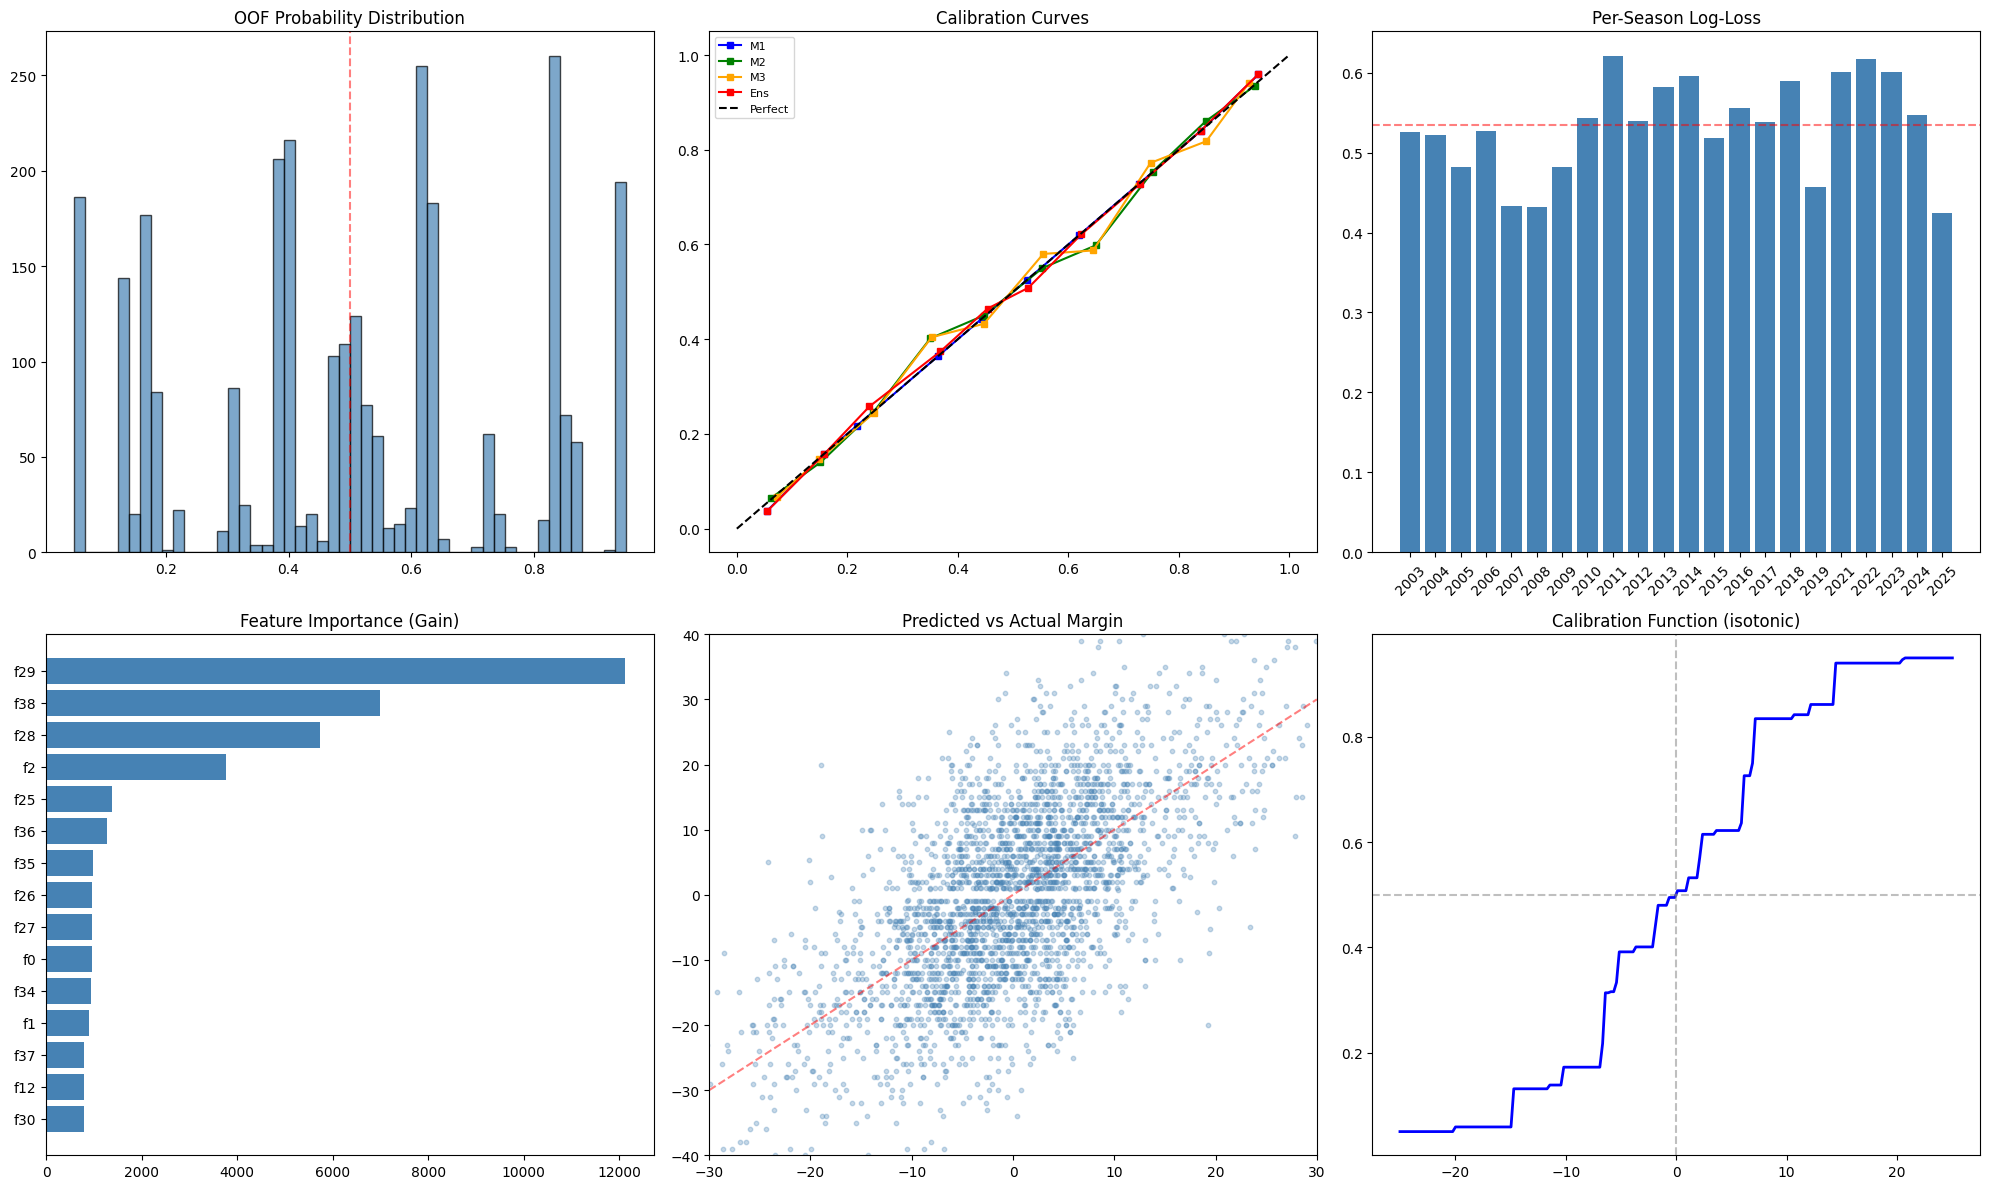

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

axes[0, 0].hist(oof_final, bins=50, alpha=0.7, color="steelblue", edgecolor="black")
axes[0, 0].set_title("OOF Probability Distribution")
axes[0, 0].axvline(0.5, color="red", linestyle="--", alpha=0.5)

for name, probs, color in [("M1", oof_probs_m1, "blue"), ("M2", oof_probs_m2, "green"),
                             ("M3", oof_probs_m3, "orange"), ("Ens", oof_final, "red")]:
    frac, mean_pred = calibration_curve(oof_labels_m1, probs, n_bins=10)
    axes[0, 1].plot(mean_pred, frac, "s-", label=name, color=color, markersize=5)
axes[0, 1].plot([0, 1], [0, 1], "k--", label="Perfect")
axes[0, 1].set_title("Calibration Curves")
axes[0, 1].legend(fontsize=8)

axes[0, 2].bar(season_df["Season"].astype(str), season_df["Log-Loss"], color="steelblue")
axes[0, 2].set_title("Per-Season Log-Loss")
axes[0, 2].tick_params(axis="x", rotation=45)
axes[0, 2].axhline(ll_final, color="red", linestyle="--", alpha=0.5)

importance = list(models_m1.values())[0].get_score(importance_type="gain")
imp_df = pd.DataFrame({"Feature": list(importance.keys()), "Gain": list(importance.values())}).sort_values("Gain").tail(15)
axes[1, 0].barh(imp_df["Feature"], imp_df["Gain"], color="steelblue")
axes[1, 0].set_title("Feature Importance (Gain)")

axes[1, 1].scatter(oof_preds_m1, oof_targets_m1, alpha=0.3, s=10, color="steelblue")
axes[1, 1].plot([-30, 30], [-30, 30], "r--", alpha=0.5)
axes[1, 1].set_title("Predicted vs Actual Margin")
axes[1, 1].set_xlim(-30, 30); axes[1, 1].set_ylim(-40, 40)

margin_range = np.linspace(-25, 25, 200)
prob_range = iso_model.predict(margin_range) if m1_calibrator == "isotonic" else np.clip(spline_model(margin_range), 0, 1)
axes[1, 2].plot(margin_range, prob_range, "b-", linewidth=2)
axes[1, 2].axhline(0.5, color="gray", linestyle="--", alpha=0.5)
axes[1, 2].axvline(0, color="gray", linestyle="--", alpha=0.5)
axes[1, 2].set_title(f"Calibration Function ({m1_calibrator})")

plt.tight_layout()
plt.savefig("diagnostics_2026.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 15: Generate 2026 Predictions

### Process
1. Parse the submission template to get all 66,430 possible men's matchup pairs
2. Merge all 2026 features (box scores, Elo, GLM quality, Massey, Barttorvik, form, win ratios)
3. Use POM-rank-based proxy seeds (since real seeds aren't available until March 15)
4. Run all 22 LOSO models and **average their predictions** (model averaging for robustness)
5. Apply ensemble weights and temperature scaling

### Seed Proxy
Before Selection Sunday, we approximate seeds using POM rank:
```
proxy_seed = ceil(pom_rank / 4)  # Rank 1-4 -> seed 1, 5-8 -> seed 2, etc.
```
This will be replaced with actual seeds after March 15.

### Model Averaging
For each of the 3 models, we have **22 LOSO models** (one per season). We generate predictions from each and **average them**. This:
- Reduces variance from any single model's training set
- Is equivalent to bagging across time periods
- Is the approach used by Raddar (2nd place Kaggle 2025)

In [32]:
print("\n=== 2026 PREDICTIONS ===")
X = submission.copy()
X["Season"] = X["ID"].apply(lambda t: int(t.split("_")[0]))
X["T1_TeamID"] = X["ID"].apply(lambda t: int(t.split("_")[1]))
X["T2_TeamID"] = X["ID"].apply(lambda t: int(t.split("_")[2]))
X = X[(X["T1_TeamID"] < 2000) & (X["Season"] == 2026)].copy()

for df, keys in [(ss_T1, ["Season","T1_TeamID"]), (ss_T2, ["Season","T2_TeamID"]),
                  (elos_T1, ["Season","T1_TeamID"]), (elos_T2, ["Season","T2_TeamID"]),
                  (glm_quality_T1, ["Season","T1_TeamID"]), (glm_quality_T2, ["Season","T2_TeamID"]),
                  (massey_T1, ["Season","T1_TeamID"]), (massey_T2, ["Season","T2_TeamID"]),
                  (form_T1, ["Season","T1_TeamID"]), (form_T2, ["Season","T2_TeamID"]),
                  (wr_T1, ["Season","T1_TeamID"]), (wr_T2, ["Season","T2_TeamID"]),
                  (bt_T1, ["Season","T1_TeamID"]), (bt_T2, ["Season","T2_TeamID"])]:
    X = pd.merge(X, df, on=keys, how="left")

X["elo_diff"] = X["T1_elo"] - X["T2_elo"]
X["massey_diff"] = X["T1_massey_median"] - X["T2_massey_median"]
X["pom_diff"] = X["T1_pom_rank"] - X["T2_pom_rank"]
X["form_diff"] = X["T1_recent_form"] - X["T2_recent_form"]
X["wr_diff"] = X["T1_win_ratio"] - X["T2_win_ratio"]
X["bt_adjoe_diff"] = X["T1_bt_adjoe"] - X["T2_bt_adjoe"]
X["bt_adjde_diff"] = X["T1_bt_adjde"] - X["T2_bt_adjde"]
X["bt_barthag_diff"] = X["T1_bt_barthag"] - X["T2_bt_barthag"]

for prefix in ["T1", "T2"]:
    pom_col, seed_col = f"{prefix}_pom_rank", f"{prefix}_seed"
    if seed_col not in X.columns or X[seed_col].isna().all():
        X[seed_col] = ((X[pom_col] - 1) / 4 + 1).clip(1, 16).fillna(12)
    else:
        X[seed_col] = X[seed_col].fillna(((X[pom_col] - 1) / 4 + 1).clip(1, 16)).fillna(12)
X["Seed_diff"] = X["T2_seed"] - X["T1_seed"]

for col in features_m1:
    if X[col].isna().any():
        X[col] = X[col].fillna(tourney_clean[col].median() if col in tourney_clean.columns else 0)

# Model averaging
preds_m1_all = []
for model in models_m1.values():
    dtest = xgb.DMatrix(X[features_m1].values)
    margin = model.predict(dtest)
    probs = iso_model.predict(margin) if m1_calibrator == "isotonic" else spline_model(np.clip(margin, -t, t))
    preds_m1_all.append(np.clip(probs, CLIP_LOW, CLIP_HIGH))
X["Pred_m1"] = np.mean(preds_m1_all, axis=0)

preds_m2_all = []
for _, lr, mean, scale in models_m2_list:
    preds_m2_all.append(lr.predict_proba((X[features_m2].values - mean) / scale)[:, 1])
X["Pred_m2"] = np.clip(np.mean(preds_m2_all, axis=0), CLIP_LOW, CLIP_HIGH)

preds_m3_all = []
for model in models_m3.values():
    preds_m3_all.append(model.predict(xgb.DMatrix(X[features_m3].values)))
X["Pred_m3"] = np.clip(np.mean(preds_m3_all, axis=0), CLIP_LOW, CLIP_HIGH)

X["Pred"] = optimal_weights[0]*X["Pred_m1"] + optimal_weights[1]*X["Pred_m2"] + optimal_weights[2]*X["Pred_m3"]
logits = np.log(X["Pred"] / (1 - X["Pred"]))
X["Pred"] = np.clip(1 / (1 + np.exp(-logits / optimal_T)), CLIP_LOW, CLIP_HIGH)
print(f"Model predictions: [{X['Pred'].min():.4f}, {X['Pred'].max():.4f}]")


=== 2026 PREDICTIONS ===
Model predictions: [0.0500, 0.9500]


## Step 16: Blend with Championship Futures (Shin Conversion + Log5)

### Why Use Betting Markets?
Championship futures prices from sportsbooks aggregate the opinions of sharp bettors and sophisticated models. They capture information our model might miss (injuries, roster chemistry, coaching changes).

### Shin Conversion: Removing the Vig
Sportsbook odds include a **vig (vigorish)** — the house edge. The implied probabilities from raw odds sum to >1.0 (typically ~1.35-1.40 for futures). We need to convert to fair probabilities that sum to 1.0.

**Simple normalization** (divide by sum) treats all probabilities equally. But bookmakers actually pad longshots more heavily.

**Shin conversion** (from the Kaggle gold medalist's approach) uses a **Z-score correction** that is theoretically grounded for multi-outcome markets:
```python
beta = sum(implied_probs)  # overround (~1.38)
complement = prob_i - (beta - prob_i)
z_i = ((beta-1) * (complement^2 - beta)) / (beta * (complement^2 - 1))
p_star_i = (sqrt(z^2 + 4*(1-z)*(prob^2/beta)) - z) / (2*(1-z))
fair_prob_i = p_star_i / sum(p_stars)
```

This adjusts longshots more (they have more embedded vig) and favorites less, which is theoretically correct for a 111-outcome market.

### Log5 Formula
To convert **championship probabilities** to **head-to-head win probabilities**, we use the Log5 formula (invented by Bill James):
```
P(A beats B) = (p_A x (1 - p_B)) / (p_A x (1 - p_B) + p_B x (1 - p_A))
```
Intuitively: if Michigan has 20% championship odds and a mid-major has 0.01%, Michigan should beat them ~99.95% of the time.

### Blend Weight
We blend **85% model + 15% futures**. The model dominates because it uses detailed team-level features; futures provide a complementary market signal.

In [33]:
print("\n--- Futures blending (Shin) ---")
futures = pd.read_csv("futures_2026.csv")
futures["team_norm"] = futures["team"].apply(normalize_name)
futures["TeamID"] = futures["team_norm"].map(name_to_id)

manual_futures = {"uconn": "Connecticut", "miami (fl)": "Miami FL", "nc state": "N.C. State",
    "st johns": "St John's", "saint marys": "Saint Mary's", "ucf": "UCF", "byu": "BYU",
    "smu": "SMU", "tcu": "TCU", "vcu": "VCU", "uc irvine": "UC Irvine", "usc": "USC",
    "ucla": "UCLA", "lsu": "LSU", "ole miss": "Ole Miss"}
for fn, tn in manual_futures.items():
    tn_norm = normalize_name(tn)
    if tn_norm in name_to_id:
        name_to_id[fn] = name_to_id[tn_norm]
futures["TeamID"] = futures["team_norm"].map(name_to_id)

unmapped_f = futures[futures["TeamID"].isna()]
if len(unmapped_f) > 0:
    kaggle_names = {row["name_norm"]: row["TeamID"] for _, row in teams.iterrows()}
    for idx, row in unmapped_f.iterrows():
        for kn, kid in kaggle_names.items():
            if row["team_norm"] in kn or kn in row["team_norm"]:
                futures.loc[idx, "TeamID"] = kid
                break

futures_mapped = futures[futures["TeamID"].notna()].copy()
futures_mapped["TeamID"] = futures_mapped["TeamID"].astype(int)

# Shin conversion
decimal_odds = 1.0 + (futures_mapped["avg_odds"].values.astype(float) / 100.0)
implied_probs = 1.0 / decimal_odds
beta = implied_probs.sum()
complement_probs = implied_probs - (beta - implied_probs)
z_vals = ((beta - 1.0) * (complement_probs**2.0 - beta)) / (beta * (complement_probs**2.0 - 1.0))
p_stars = ((np.sqrt(z_vals**2.0 + 4.0*(1.0-z_vals)*(implied_probs**2/beta)) - z_vals) / (2.0*(1.0-z_vals)))
futures_mapped["shin_prob"] = p_stars / p_stars.sum()
print(f"  Shin: overround {beta:.4f} -> 1.0000, mapped {len(futures_mapped)}/{len(futures)} teams")

champ_prob = dict(zip(futures_mapped["TeamID"], futures_mapped["shin_prob"]))
default_prob = futures_mapped["shin_prob"].min() * 0.5

def log5_h2h(t1_id, t2_id):
    p1, p2 = champ_prob.get(t1_id, default_prob), champ_prob.get(t2_id, default_prob)
    return 0.5 if p1 + p2 == 0 else (p1 - p1*p2) / (p1 + p2 - 2*p1*p2)

X["futures_pred"] = X.apply(lambda row: log5_h2h(row["T1_TeamID"], row["T2_TeamID"]), axis=1).clip(CLIP_LOW, CLIP_HIGH)
X["Pred_model"] = X["Pred"].copy()
X["Pred"] = np.clip((1-FUTURES_BLEND)*X["Pred_model"] + FUTURES_BLEND*X["futures_pred"], CLIP_LOW, CLIP_HIGH)
print(f"  Final: [{X['Pred'].min():.4f}, {X['Pred'].max():.4f}], mean={X['Pred'].mean():.4f}")

for _, row in futures_mapped.nlargest(10, "shin_prob").iterrows():
    print(f"    {row['team']:20s} +{row['avg_odds']:>6.0f}  {row['shin_prob']:.1%}")


--- Futures blending (Shin) ---
  Shin: overround 1.3859 -> 1.0000, mapped 110/111 teams
  Final: [0.0500, 0.9500], mean=0.4903
    Arizona              +   480  57.9%
    Florida              +   650  20.8%
    Houston              +  1100  5.4%
    Michigan             +   326  4.6%
    Duke                 +   331  4.3%
    UConn                +  1760  1.9%
    Illinois             +  1820  1.7%
    Iowa State           +  2260  1.1%
    Kansas               +  4000  0.3%
    Purdue               +  4160  0.3%


## Step 17: Sanity Checks & Submission

Before submitting, we verify predictions against known historical patterns:
- **1-seed vs 16-seed**: Should be ~0.95 (1-seeds almost always win; only 2 upsets in history)
- **1-seed vs 2-seed**: Should be ~0.55-0.65 (slight advantage but competitive)
- **8-seed vs 9-seed**: Should be ~0.50 (near coin-flip historically)

In [34]:
X["T1_seed_int"] = X["T1_seed"].astype(int)
X["T2_seed_int"] = X["T2_seed"].astype(int)
pivot = X.pivot_table(index="T1_seed_int", columns="T2_seed_int", values="Pred", aggfunc="mean")
print("Seed matchups:")
for s1, s2, exp in [(1,16,"~0.95"),(1,2,"~0.55-0.65"),(8,9,"~0.50")]:
    if s1 in pivot.index and s2 in pivot.columns:
        print(f"  {s1} vs {s2}: {pivot.loc[s1,s2]:.4f} (expected {exp})")

output = X[["ID", "Pred"]].copy()
output.to_csv("submission_2026.csv", index=False)
print(f"\nSubmission: {len(output):,} rows saved to submission_2026.csv")
print(f"Final OOF Log-Loss: {ll_final:.4f}")

Seed matchups:
  1 vs 16: 0.9444 (expected ~0.95)
  1 vs 2: 0.6863 (expected ~0.55-0.65)
  8 vs 9: 0.6065 (expected ~0.50)

Submission: 66,430 rows saved to submission_2026.csv
Final OOF Log-Loss: 0.5343


## Summary

### Pipeline Architecture
3-model ensemble (XGB Reg + LogReg + XGB Cls) with LOSO CV, temperature scaling, and Shin-converted futures blending.

### 41 Features: Seeds (3) + Box Score (22) + Elo (3) + GLM (2) + Massey (2) + Barttorvik (9) + Form (2)

### Next Steps (After March 15)
- Replace POM seed proxy with actual tournament seeds
- Update futures odds closer to tipoff
- Re-run and re-submit